# 01. Energy Consumption Forecasting: EDA & Preprocessing
This notebook focuses on exploring the "Appliances Energy Prediction" dataset. Our goal is to analyze temporal patterns, identify key influencers of energy consumption, and prepare the data for a Deep Learning model (PyTorch).

## 1. Environment Setup & Data Acquisition

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [ ]:
#import dataset
data_path = Path.cwd().parent / 'data' / 'raw' / 'energydata_complete.csv'
if data_path.exists():
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully")
else:
    print("Path data does not exist")

## 2.Explore dataset

In [27]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [29]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [30]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [31]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

In [32]:
# Check if the time gaps are all exactly 10 minutes
time_diffs = df.index.to_series().diff().value_counts()
print("Time Step Distribution:\n", time_diffs)

Time Step Distribution:
 date
0 days 00:10:00    19734
Name: count, dtype: int64


In [33]:
df.tail(1)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-05-27 18:00:00,430,10,25.5,46.6,25.264286,42.971429,26.823333,41.156667,24.7,45.963333,...,23.2,46.845,22.2,755.2,57.0,4.0,27.0,13.2,34.118851,34.118851


In each 10 minutes we have a new observation

### Seasonal Plots

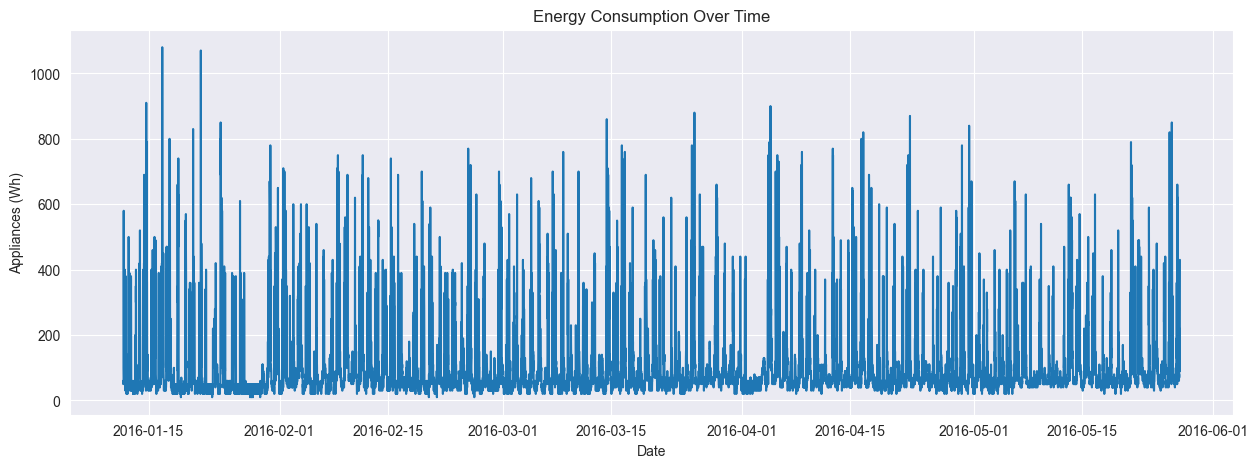

In [34]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['Appliances'])
plt.title('Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Appliances (Wh)')
plt.show()

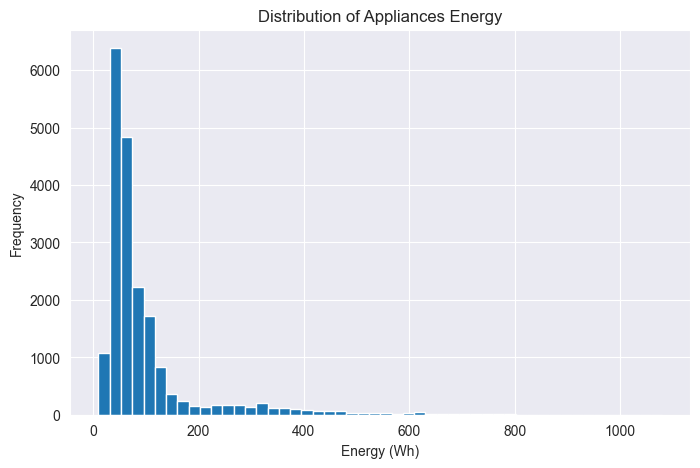

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df['Appliances'], bins=50)
plt.title('Distribution of Appliances Energy')
plt.xlabel('Energy (Wh)')
plt.ylabel('Frequency')
plt.show()

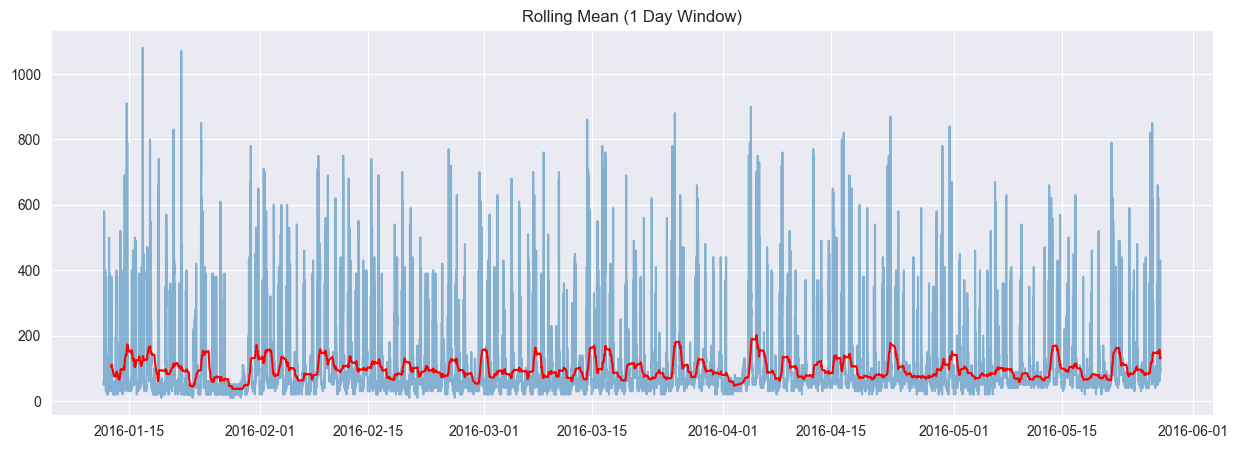

In [36]:
rolling_mean = df['Appliances'].rolling(window=144).mean()

plt.figure(figsize=(15,5))
plt.plot(df['Appliances'], alpha=0.5)
plt.plot(rolling_mean, color='red')
plt.title('Rolling Mean (1 Day Window)')
plt.show()

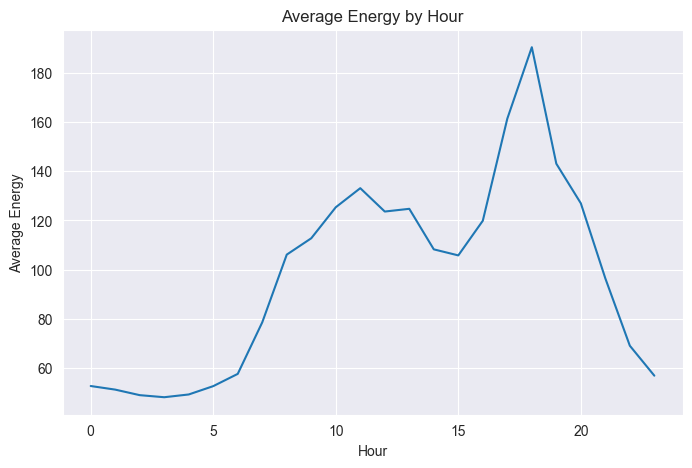

In [37]:
df['hour'] = df.index.hour
hourly_avg = df.groupby('hour')['Appliances'].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly_avg)
plt.title('Average Energy by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Energy')
plt.show()

In [38]:
df.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2', 'hour'],
      dtype='str')

In [39]:
df["day"] = df.index.day
df["month"] = df.index.month
df['is_weekend'] = (df['day'] >= 5).astype(int)

<Figure size 640x480 with 0 Axes>

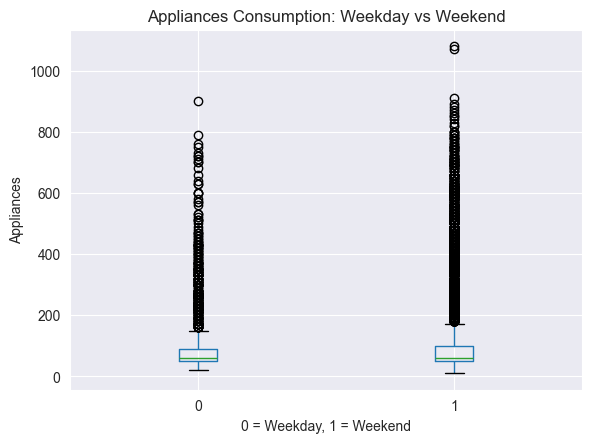

In [40]:
plt.figure()
df.boxplot(column='Appliances', by='is_weekend')
plt.title("Appliances Consumption: Weekday vs Weekend")
plt.suptitle("")
plt.xlabel("0 = Weekday, 1 = Weekend")
plt.ylabel("Appliances")
plt.show()

- ACF :measures the relationship between the current energy usage and its past.
=> tells us if the data has a trend
- PACF: It measures the relationship between two times by removing the influence of everything that happened in between
=> tells us exactly how many lags to use as inputs for our AI.


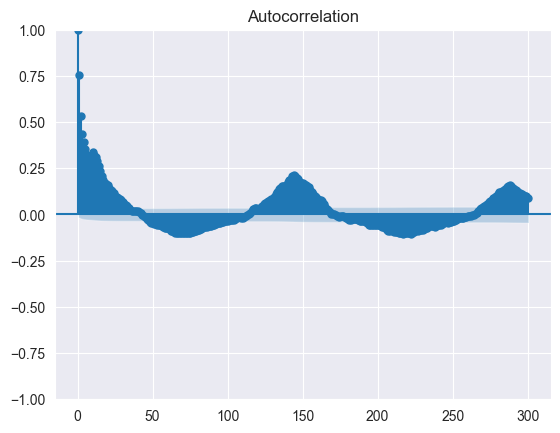

In [41]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['Appliances'], lags=300)
plt.show()

- Strong Positive Autocorrelation at Low Lags
- Slow Decay of Autocorrelation
The ACF values decrease gradually rather than dropping quickly toward zero.
This slow decay suggests that the series is non-stationary, meaning the statistical properties (mean and variance) are not constant over time.
- Clear Seasonal Pattern
The ACF exhibits repeating peaks around lag 144 and its multiples.
Since the data is recorded every 10 minutes, 144 lags correspond to 24 hours.
=>This confirms the presence of strong daily seasonality in energy consumption.


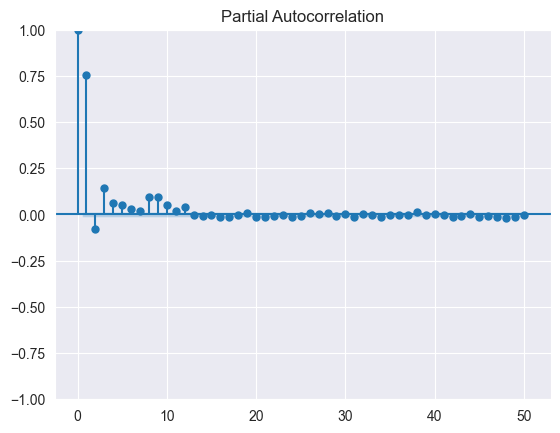

In [42]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['Appliances'], lags=50)
plt.show()

Lag 1 (~0.75): The strongest predictor of energy use right now is what the energy use was 10 minutes ago.

Lag 2: There is still a small significant relationship here.

The "Cut-off": After Lag 2 or 3, the bars crash into the "noise".

In [43]:
df['lag_1'] = df['Appliances'].shift(1)
df['lag_2'] = df['Appliances'].shift(2)
df['lag_6'] = df['Appliances'].shift(6)
df['lag_144'] = df['Appliances'].shift(144)

In [44]:
df.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2', 'hour', 'day', 'month', 'is_weekend',
       'lag_1', 'lag_2', 'lag_6', 'lag_144'],
      dtype='str')

## Split the data

In time series we can not shuffle the data or split randomly , instead I will chose the first 80% for training and the last 20% for testing

In [45]:
cut_off = int(len(df)*0.8)
train = df.iloc[:cut_off , :]
test = df.iloc[cut_off : , :]

## Build the model

ARIMAX Model

Instead of using a seasonal SARIMA model, we use an ARIMAX model.

ARIMAX extends ARIMA by including exogenous variables (external predictors).

In this dataset, energy consumption is strongly influenced by:

- Indoor temperature and humidity

- Outdoor temperature

- Time-related features (hour, weekend)

- Lagged consumption values

Using ARIMAX allows the model to capture:

- Temporal dependency

- Trend

- Influence of environmental variables

=> This approach reduces computational complexity compared to SARIMA with large seasonal periods.

In [ ]:
exog_features = [
    'T_out',
    'RH_out',
    'hour',
    'is_weekend',
    'lag_1',
    'lag_2'
]

X_train = train[exog_features]
X_test = test[exog_features]

In [ ]:
print(5)